In [1]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
# Download the dataset - Breast Cancer Gene Expression data
import urllib.request

url = "https://raw.githubusercontent.com/selva86/datasets/master/BreastCancer.csv"
urllib.request.urlretrieve(url, "breast_cancer.csv")

df = pd.read_csv("breast_cancer.csv")
print("Dataset loaded!")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Dataset loaded!
Shape: (699, 11)

First 5 rows:


,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,0
1,1002945,5,4,4,5,7,10.0,3,2,1,0
2,1015425,3,1,1,1,2,2.0,3,1,1,0
3,1016277,6,8,8,1,3,4.0,3,7,1,0
4,1017023,4,1,1,3,2,1.0,3,1,1,0


In [3]:
# Basic exploration
print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nClass distribution (0=Benign, 1=Malignant):")
print(df['Class'].value_counts())
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()


Dataset Shape: (699, 11)

Column Names: ['Id', 'Cl.thickness', 'Cell.size', 'Cell.shape', 'Marg.adhesion', 'Epith.c.size', 'Bare.nuclei', 'Bl.cromatin', 'Normal.nucleoli', 'Mitoses', 'Class']

Class distribution (0=Benign, 1=Malignant):
Class
0    458
1    241
Name: count, dtype: int64

Missing values:
Id                  0
Cl.thickness        0
Cell.size           0
Cell.shape          0
Marg.adhesion       0
Epith.c.size        0
Bare.nuclei        16
Bl.cromatin         0
Normal.nucleoli     0
Mitoses             0
Class               0
dtype: int64

Basic Statistics:


,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413,0.344778
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078,0.475636
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,0.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,0.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,1.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000


In [8]:
# Clean the data - fill missing values with median (pandas 3.0 compatible)
df['Bare.nuclei'] = df['Bare.nuclei'].fillna(df['Bare.nuclei'].median())

# Drop the ID column (not useful for analysis)
df = df.drop('Id', axis=1, errors='ignore')

print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nData is clean and ready for analysis!")

Missing values after cleaning:
Cl.thickness       0
Cell.size          0
Cell.shape         0
Marg.adhesion      0
Epith.c.size       0
Bare.nuclei        0
Bl.cromatin        0
Normal.nucleoli    0
Mitoses            0
Class              0
dtype: int64

Data is clean and ready for analysis!


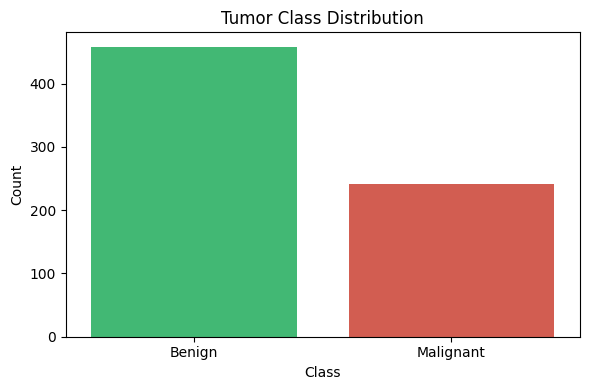

Plot 1 saved!


In [9]:
# Plot 1 - Class Distribution (Benign vs Malignant)
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', hue='Class', data=df, palette=['#2ecc71', '#e74c3c'], legend=False)
plt.xticks([0, 1], ['Benign', 'Malignant'])
plt.title('Tumor Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("Plot 1 saved!")

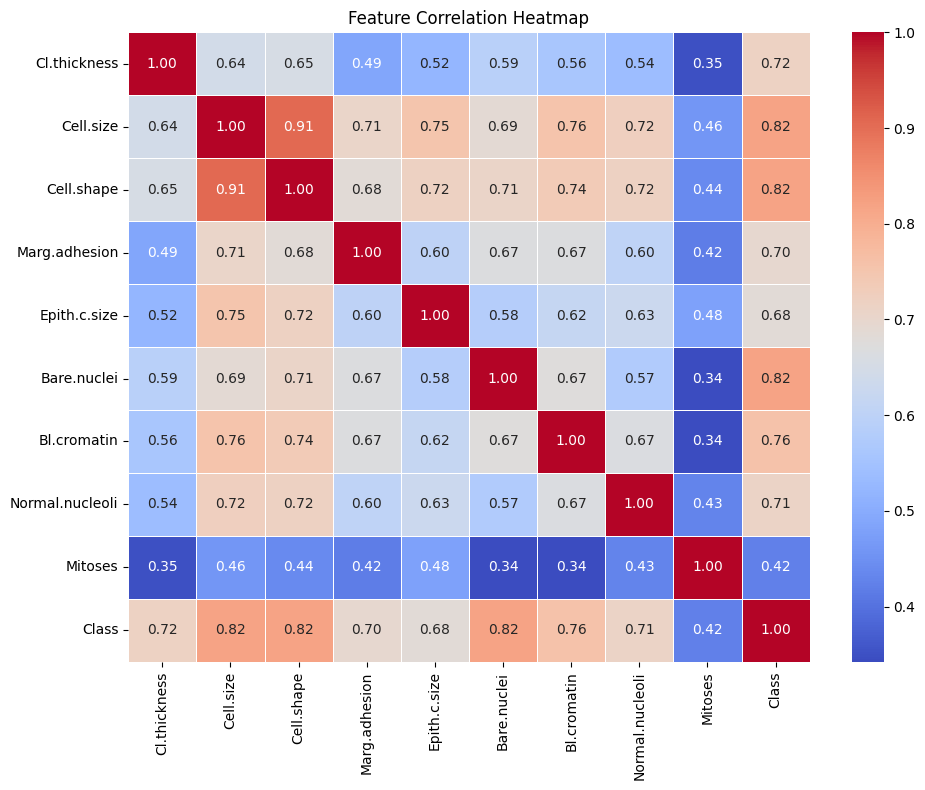

Plot 2 saved!


In [10]:
# Plot 2 - Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print("Plot 2 saved!")

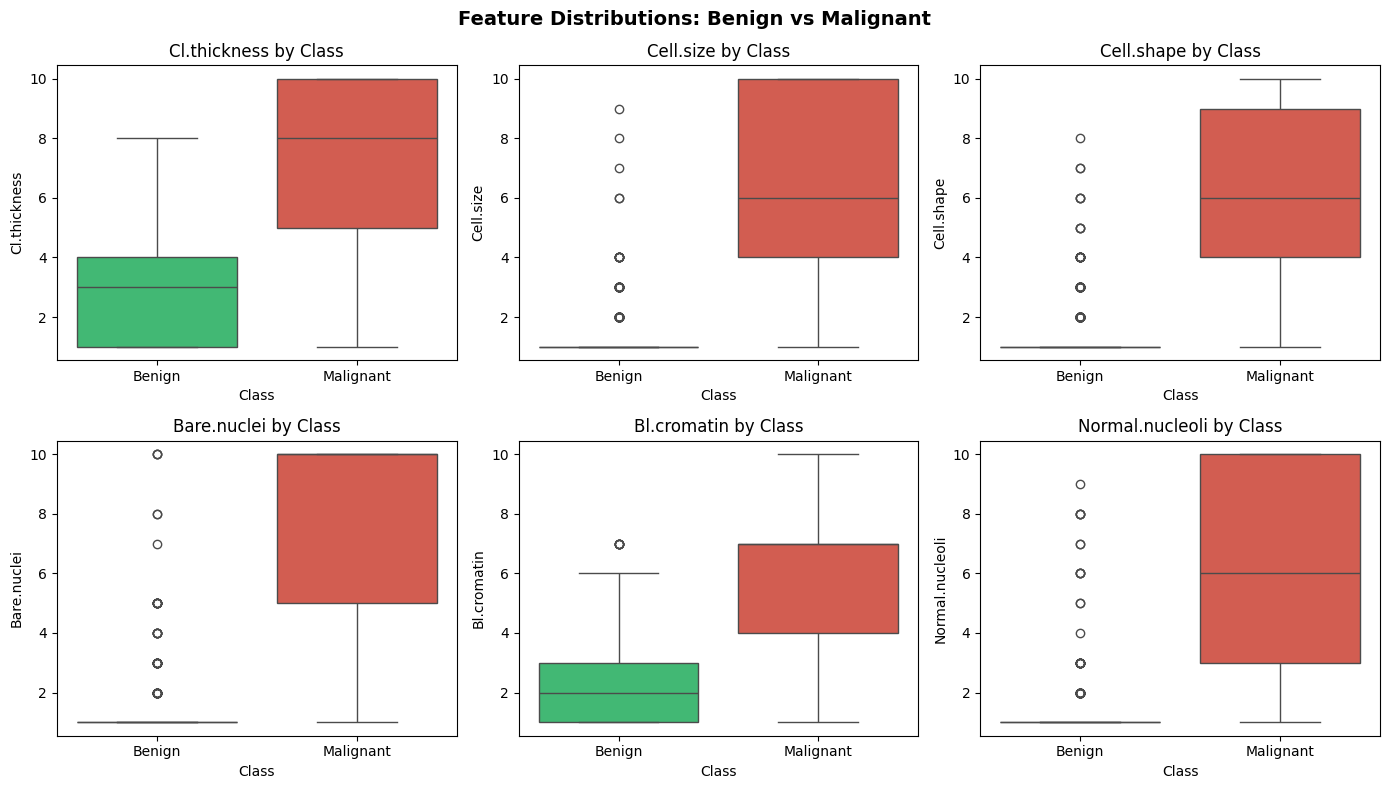

Plot 3 saved!


In [12]:
# Plot 3 - Feature Distribution by Class
features = ['Cl.thickness', 'Cell.size', 'Cell.shape', 'Bare.nuclei', 'Bl.cromatin', 'Normal.nucleoli']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x='Class', hue='Class', data=df, y=feature,
                palette=['#2ecc71', '#e74c3c'], legend=False, ax=axes[i])
    axes[i].set_title(f'{feature} by Class')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Benign', 'Malignant'])

plt.suptitle('Feature Distributions: Benign vs Malignant', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()
print("Plot 3 saved!")

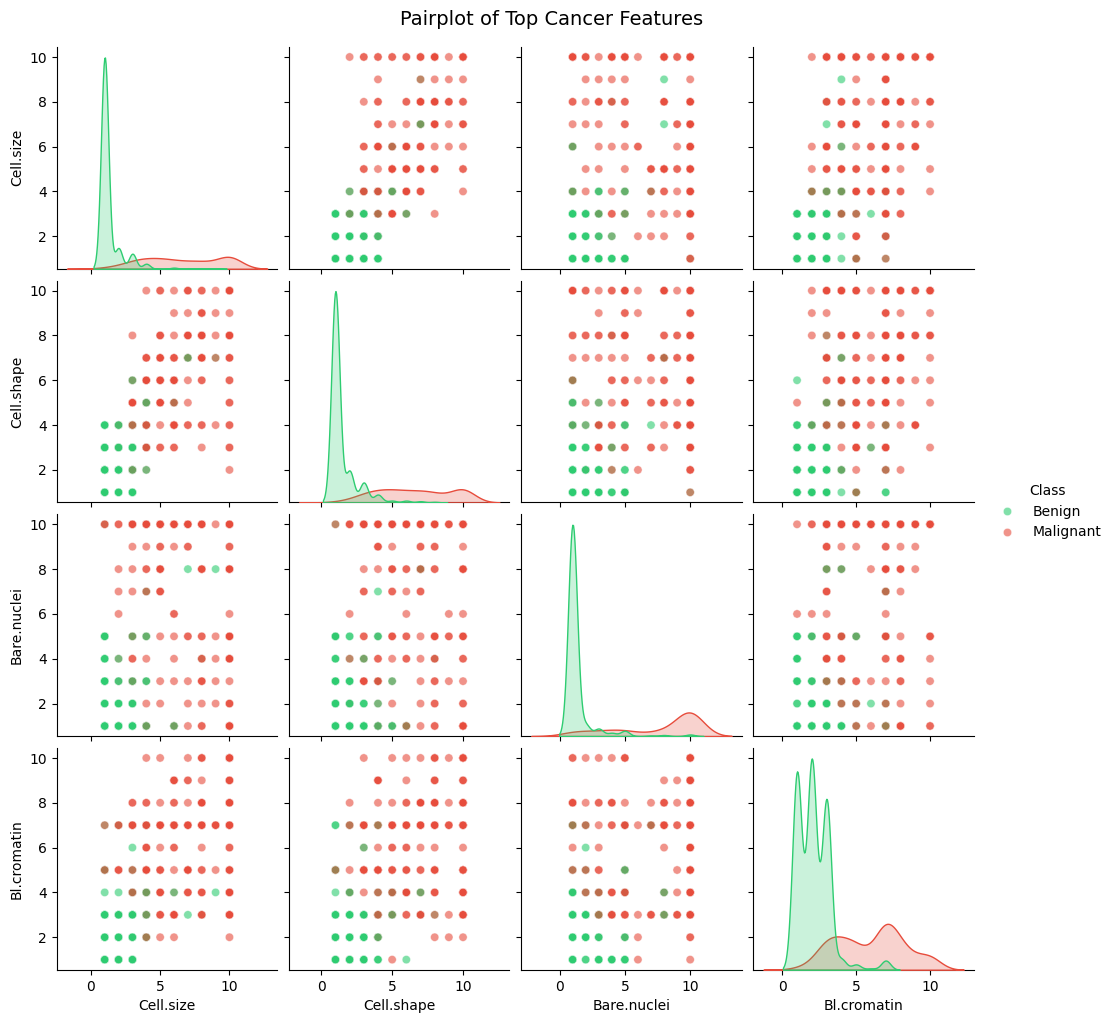

Plot 4 saved!


In [13]:
# Plot 4 - Pairplot of top features
top_features = ['Cell.size', 'Cell.shape', 'Bare.nuclei', 'Bl.cromatin', 'Class']
pair_df = df[top_features].copy()
pair_df['Class'] = pair_df['Class'].map({0: 'Benign', 1: 'Malignant'})

sns.pairplot(pair_df, hue='Class', palette={'Benign': '#2ecc71', 'Malignant': '#e74c3c'}, 
             plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of Top Cancer Features', y=1.02, fontsize=14)
plt.savefig('pairplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 saved!")

In [14]:
# Summary of Key Findings
print("=" * 50)
print("       GENOMIC EDA - KEY FINDINGS SUMMARY")
print("=" * 50)

print(f"\n Total Samples: {len(df)}")
print(f" Benign Cases: {(df['Class']==0).sum()} ({(df['Class']==0).mean()*100:.1f}%)")
print(f" Malignant Cases: {(df['Class']==1).sum()} ({(df['Class']==1).mean()*100:.1f}%)")

print("\n Top Features Correlated with Malignancy:")
corr = df.corr()['Class'].drop('Class').sort_values(ascending=False)
for feat, val in corr.items():
    print(f"  {feat:<20} correlation: {val:.3f}")

print("\n Plots saved:")
print("  class_distribution.png")
print("  correlation_heatmap.png")
print("  feature_distributions.png")
print("  pairplot.png")

print("\n Project Complete! Ready for GitHub.")
print("=" * 50)

       GENOMIC EDA - KEY FINDINGS SUMMARY

 Total Samples: 699
 Benign Cases: 458 (65.5%)
 Malignant Cases: 241 (34.5%)

 Top Features Correlated with Malignancy:
  Bare.nuclei          correlation: 0.819
  Cell.shape           correlation: 0.819
  Cell.size            correlation: 0.818
  Bl.cromatin          correlation: 0.757
  Cl.thickness         correlation: 0.716
  Normal.nucleoli      correlation: 0.712
  Marg.adhesion        correlation: 0.697
  Epith.c.size         correlation: 0.683
  Mitoses              correlation: 0.423

 Plots saved:
  class_distribution.png
  correlation_heatmap.png
  feature_distributions.png
  pairplot.png

 Project Complete! Ready for GitHub.


In [16]:
import os
print(os.getcwd())

C:\Users\gsait\Desktop\genomic-eda-project
